# Chapter 7 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 7: The COVID-19 Inflection**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

The chapter's claim is that the SY2020-21 rate rise is a denominator (enrollment) shock, not numerator (identification) growth. The analysis separates the two components explicitly.

In [1]:
import sqlite3, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. Served, enrollment, and rate (full series)

In [2]:
d = q('''SELECT d.school_year AS sy, SUM(d.n_students) AS served, SUM(e.n_total) AS enroll,
                100.0*SUM(d.n_students)/SUM(e.n_total) AS rate
         FROM fact_state_disability d JOIN fact_state_enrollment e
           ON d.school_year=e.school_year AND d.state_code=e.state_code
         WHERE d.disability_code='ALL' AND d.age_band='ALL'
         GROUP BY 1 ORDER BY 1''')
d['served_yoy'] = d['served'].pct_change()*100
d['enroll_yoy'] = d['enroll'].pct_change()*100
d['rate_pp']    = d['rate'].diff()
years = list(d['sy'])
d[d['sy'].between('2018-19','2023-24')][['sy','served_yoy','enroll_yoy','rate_pp']].round(2)

,sy,served_yoy,enroll_yoy,rate_pp
13,2018-19,5.30,0.02,0.69
14,2019-20,0.88,0.20,0.09
15,2020-21,0.30,-2.80,0.44
16,2021-22,1.08,0.12,0.14
17,2022-23,4.92,0.37,0.66
18,2023-24,3.42,-0.21,0.55


## 2. The denominator shock (Figure 7.1)

Served and enrollment indexed to SY2018-19. In the shaded pandemic window the enrollment line drops while the served line holds - the rate rises because the denominator shrank.

saved


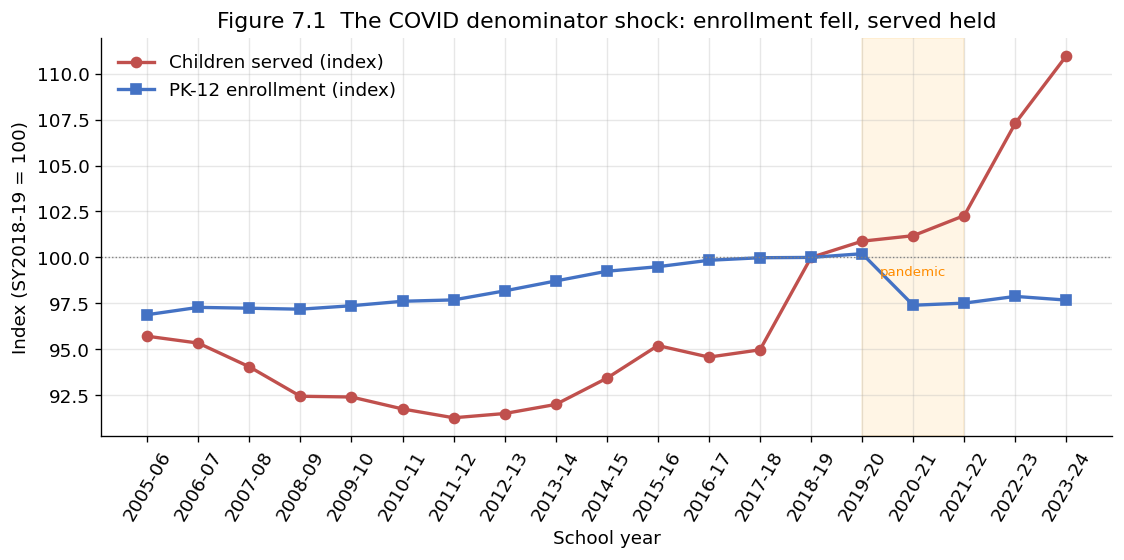

In [3]:
base = d[d['sy']=='2018-19'].iloc[0]
fig, ax = plt.subplots(figsize=(9.5,4.8))
ax.plot(years, 100*d['served']/base['served'], marker='o', color='#c0504d', lw=2, label='Children served (index)')
ax.plot(years, 100*d['enroll']/base['enroll'], marker='s', color='#4472c4', lw=2, label='PK-12 enrollment (index)')
ax.axvspan('2019-20','2021-22', alpha=0.10, color='orange')
ax.axhline(100, color='gray', ls=':', lw=0.8)
ax.text('2020-21', 99.0, 'pandemic', ha='center', fontsize=8, color='darkorange')
ax.set_ylabel('Index (SY2018-19 = 100)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False, loc='upper left')
ax.set_title('Figure 7.1  The COVID denominator shock: enrollment fell, served held')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig7_1_covid_shock.png', bbox_inches='tight')
print('saved')

## 3. Component decomposition (Figure 7.2)

saved


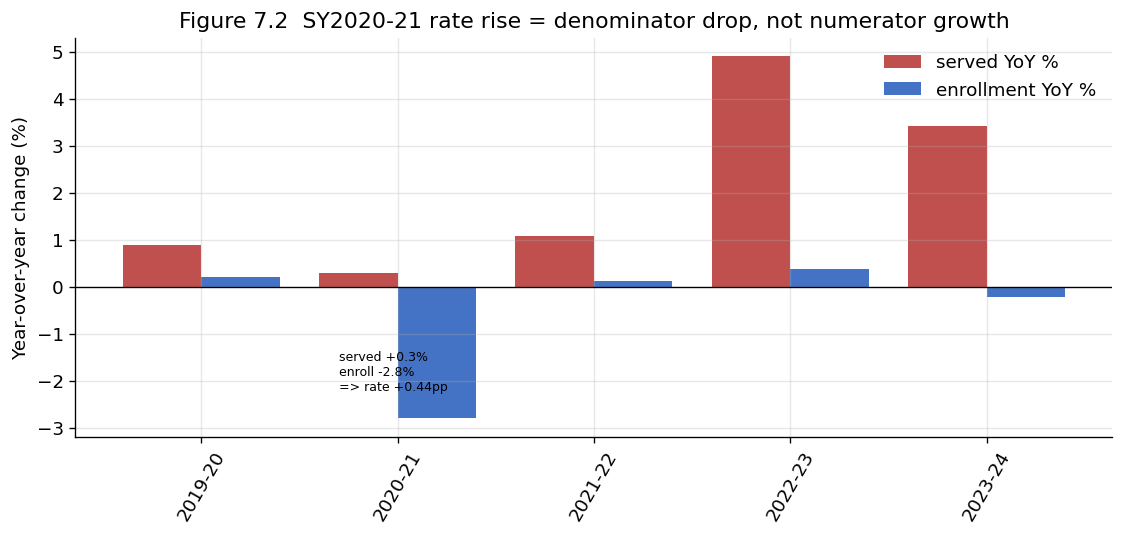

In [4]:
sub = d[d['sy'].between('2019-20','2023-24')]
x = np.arange(len(sub))
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.bar(x-0.2, sub['served_yoy'], 0.4, label='served YoY %', color='#c0504d')
ax.bar(x+0.2, sub['enroll_yoy'], 0.4, label='enrollment YoY %', color='#4472c4')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(sub['sy'], rotation=60)
ax.set_ylabel('Year-over-year change (%)'); ax.legend(frameon=False)
ax.set_title('Figure 7.2  SY2020-21 rate rise = denominator drop, not numerator growth')
i = list(sub['sy']).index('2020-21')
ax.annotate('served +0.3%\nenroll -2.8%\n=> rate +0.44pp', xy=(i,-2.8), xytext=(i-0.3,-2.2), fontsize=7.5)
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig7_2_decomposition.png', bbox_inches='tight')
print('saved')

## 4. Category composition of the pandemic year (Table 7.1 inputs)

The flat national numerator hides category movement. SLD/ID/MD fell; SLI and DD rose - but the SLI/DD jump is confounded with the SY2020-21 age-5 reclassification, so it is NOT a clean COVID effect. 6-21 band, Iowa excluded.

In [5]:
cats = ['SLD','SLI','OHI','AUT','ID','ED','DD','MD']
catlist = ','.join(f"'{x}'" for x in cats)
cc = q(f'''SELECT school_year AS sy, disability_code AS dc, SUM(n_students) AS n
           FROM fact_state_disability
           WHERE age_band='6-21' AND disability_code IN ({catlist})
             AND NOT (state_code='IA' AND school_year>='2019-20')
             AND school_year IN ('2019-20','2020-21') GROUP BY 1,2''')
piv = cc.pivot(index='dc', columns='sy', values='n')
piv['pct_change'] = 100*(piv['2020-21']/piv['2019-20']-1)
piv.sort_values('pct_change').round(1)

sy,2019-20,2020-21,pct_change
dc,,,
SLD,2330427,2276389,-2.3
MD,124977,122596,-1.9
ID,410519,403396,-1.7
ED,343535,343913,0.1
OHI,1048654,1072195,2.2
AUT,698140,761552,9.1
SLI,1029005,1165937,13.3
DD,177342,254919,43.7


## 5. How many states actually saw served decline?

In [6]:
st = q('''SELECT state_code AS st,
            SUM(CASE WHEN school_year='2019-20' THEN n_students ELSE 0 END) AS y19,
            SUM(CASE WHEN school_year='2020-21' THEN n_students ELSE 0 END) AS y20
          FROM fact_state_disability
          WHERE disability_code='ALL' AND age_band='ALL'
            AND school_year IN ('2019-20','2020-21') GROUP BY 1''')
st['change'] = st['y20'] - st['y19']
print(f"States with served DECLINE 2019-20 -> 2020-21: {(st['change']<0).sum()} of {len(st)}")
print('National served YoY: +0.30% (the decline in most states is masked by growth in a few large ones)')

States with served DECLINE 2019-20 -> 2020-21: 34 of 51
National served YoY: +0.30% (the decline in most states is masked by growth in a few large ones)


In [7]:
con.close()
print('Chapter 7 figures written to', FIGDIR)

Chapter 7 figures written to figures
